# **Importing Libraries**

In [2]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.2 MB/s eta 0:00:00a 0:00:01


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch_geometric.transforms as T
from torch_geometric.datasets import ModelNet
from torch_geometric.loader import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# **Configurations**

In [4]:
BATCH_SIZE = 16  # Reduced to 16 to prevent Out Of Memory (OOM) errors with EdgeConv
NUM_POINTS = 1024
EPOCHS = 15
LEARNING_RATE = 0.001
K_NEIGHBORS = 20

In [5]:
CATEGORIES = [
    'airplane', 'bathtub', 'bed', 'bench', 'bookshelf', 'bottle', 'bowl', 'car', 'chair',
    'cone', 'cup', 'curtain', 'desk', 'door', 'dresser', 'flower_pot', 'glass_box',
    'guitar', 'keyboard', 'lamp', 'laptop', 'mantel', 'monitor', 'night_stand',
    'person', 'piano', 'plant', 'radio', 'range_hood', 'sink', 'sofa', 'stairs',
    'stool', 'tent', 'toilet', 'tv_stand', 'vase', 'wardrobe', 'xbox'
]

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# **Visualization Functions**

In [7]:
def plot_3d_point_cloud(points, title):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    x, y, z = points[0, :], points[1, :], points[2, :]
    ax.scatter(x, y, z, c=z, cmap='viridis', s=10, alpha=0.8, edgecolors='none')
    ax.set_title(title)
    ax.set_axis_off()
    plt.show()

In [8]:
def visualize_initial_data(loader, num_samples=2):
    print("--- Visualizing Initial Training Data ---")
    data = next(iter(loader))
    points = data.pos.view(-1, NUM_POINTS, 3).transpose(1, 2).cpu().numpy()
    labels = data.y.cpu().numpy()
    for i in range(num_samples):
        class_name = CATEGORIES[labels[i]] if labels[i] < len(CATEGORIES) else str(labels[i])
        plot_3d_point_cloud(points[i], title=f"Initial Data Sample: {class_name}")

In [9]:
def plot_training_curves(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss', marker='o')
    ax1.set_title('DGCNN: Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True)

    ax2.plot(epochs, history['train_acc'], 'b-', label='Train Acc', marker='o')
    ax2.plot(epochs, history['test_acc'], 'g-', label='Test Acc', marker='s')
    ax2.set_title('DGCNN: Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()

In [10]:
def visualize_predictions(model, loader, device, num_samples=3):
    print("\n--- Visualizing Final Model Predictions ---")
    model.eval()
    data = next(iter(loader))
    points_tensor = data.pos.view(-1, NUM_POINTS, 3).transpose(1, 2).to(device)
    labels = data.y.cpu().numpy()
    points_np = points_tensor.cpu().numpy()

    with torch.no_grad():
        outputs = model(points_tensor)
        _, preds = torch.max(outputs.data, 1)
        preds = preds.cpu().numpy()

    for i in range(num_samples):
        true_class = CATEGORIES[labels[i]] if labels[i] < len(CATEGORIES) else str(labels[i])
        pred_class = CATEGORIES[preds[i]] if preds[i] < len(CATEGORIES) else str(preds[i])
        title_color = "green" if true_class == pred_class else "red"

        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(points_np[i, 0, :], points_np[i, 1, :], points_np[i, 2, :], c=points_np[i, 2, :], cmap='viridis', s=10, alpha=0.8)
        ax.set_title(f"True: {true_class} | Pred: {pred_class}", color=title_color, fontweight='bold')
        ax.set_axis_off()
        plt.show()

# **Model Architecture**

In [11]:
# DGCNN ARCHITECTURE :

def knn(x, k):
    inner = -2 * torch.matmul(x.transpose(2, 1), x)
    xx = torch.sum(x**2, dim=1, keepdim=True)
    pairwise_distance = -xx - inner - xx.transpose(2, 1)
    idx = pairwise_distance.topk(k=k, dim=-1)[1]
    return idx

def get_graph_feature(x, k=20, idx=None):
    bs, dims, num_points = x.size()
    x = x.view(bs, -1, num_points)
    if idx is None:
        idx = knn(x, k=k)
    device = x.device
    idx_base = torch.arange(0, bs, device=device).view(-1, 1, 1) * num_points
    idx = (idx + idx_base).view(-1)
    x = x.transpose(2, 1).contiguous()
    feature = x.view(bs * num_points, -1)[idx, :].view(bs, num_points, k, dims)
    x = x.view(bs, num_points, 1, dims).repeat(1, 1, k, 1)
    return torch.cat((feature - x, x), dim=3).permute(0, 3, 1, 2).contiguous()

class DGCNNClassifier(nn.Module):
    def __init__(self, k=20, num_classes=40):
        super().__init__()
        self.k = k
        self.conv1 = nn.Sequential(nn.Conv2d(6, 64, kernel_size=1, bias=False), nn.BatchNorm2d(64), nn.LeakyReLU(negative_slope=0.2))
        self.conv2 = nn.Sequential(nn.Conv2d(128, 64, kernel_size=1, bias=False), nn.BatchNorm2d(64), nn.LeakyReLU(negative_slope=0.2))
        self.conv3 = nn.Sequential(nn.Conv2d(128, 128, kernel_size=1, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(negative_slope=0.2))
        self.conv4 = nn.Sequential(nn.Conv2d(256, 256, kernel_size=1, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(negative_slope=0.2))
        self.conv5 = nn.Sequential(nn.Conv1d(512, 1024, kernel_size=1, bias=False), nn.BatchNorm1d(1024), nn.LeakyReLU(negative_slope=0.2))
        self.linear1 = nn.Linear(2048, 512, bias=False)
        self.bn6 = nn.BatchNorm1d(512)
        self.dp1 = nn.Dropout(p=0.5)
        self.linear2 = nn.Linear(512, 256)
        self.bn7 = nn.BatchNorm1d(256)
        self.dp2 = nn.Dropout(p=0.5)
        self.linear3 = nn.Linear(256, num_classes)

    def forward(self, x):
        bs = x.size(0)
        x = get_graph_feature(x, k=self.k)
        x = self.conv1(x)
        x1 = x.max(dim=-1, keepdim=False)[0]

        x = get_graph_feature(x1, k=self.k)
        x = self.conv2(x)
        x2 = x.max(dim=-1, keepdim=False)[0]

        x = get_graph_feature(x2, k=self.k)
        x = self.conv3(x)
        x3 = x.max(dim=-1, keepdim=False)[0]

        x = get_graph_feature(x3, k=self.k)
        x = self.conv4(x)
        x4 = x.max(dim=-1, keepdim=False)[0]

        x = torch.cat((x1, x2, x3, x4), dim=1)
        x = self.conv5(x)

        x1 = F.adaptive_max_pool1d(x, 1).view(bs, -1)
        x2 = F.adaptive_avg_pool1d(x, 1).view(bs, -1)
        x = torch.cat((x1, x2), 1)

        x = F.leaky_relu(self.bn6(self.linear1(x)), negative_slope=0.2)
        x = self.dp1(x)
        x = F.leaky_relu(self.bn7(self.linear2(x)), negative_slope=0.2)
        x = self.dp2(x)
        return self.linear3(x)

# **Loading Data \& Augmentations**

In [12]:
train_transforms = T.Compose([T.SamplePoints(NUM_POINTS), T.NormalizeScale()])
test_transforms = T.Compose([T.SamplePoints(NUM_POINTS), T.NormalizeScale()])

In [13]:
train_dataset = ModelNet(root='data/ModelNet40', name='40', train=True, transform=train_transforms)
test_dataset = ModelNet(root='data/ModelNet40', name='40', train=False, transform=test_transforms)

Extracting data/ModelNet40/ModelNet40.zip
Processing...
Done!


In [14]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

--- Visualizing Initial Training Data ---


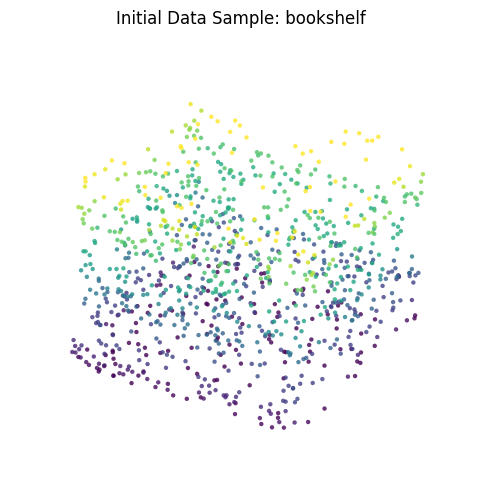

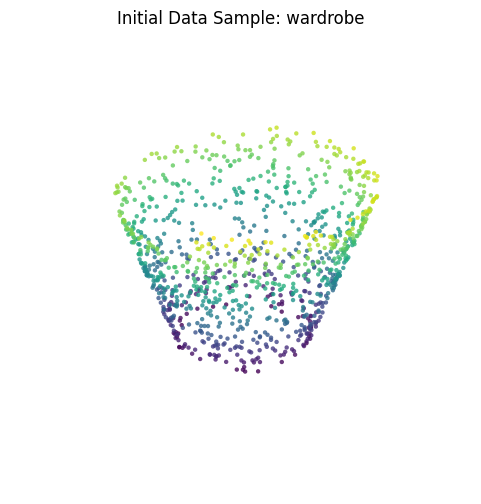

In [15]:
visualize_initial_data(train_loader, num_samples=2)

# **Training Loop**

In [16]:
model = DGCNNClassifier(k=K_NEIGHBORS, num_classes=40).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [17]:
history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

print("\n--- Starting Training ---")
for epoch in range(EPOCHS):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for data in train_loader:
        points = data.pos.view(-1, NUM_POINTS, 3).transpose(1, 2).to(device)
        labels = data.y.to(device)

        optimizer.zero_grad()
        outputs = model(points)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total

    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for data in test_loader:
            points = data.pos.view(-1, NUM_POINTS, 3).transpose(1, 2).to(device)
            labels = data.y.to(device)
            outputs = model(points)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_acc = 100 * test_correct / test_total

    history['train_loss'].append(train_loss/len(train_loader))
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")


--- Starting Training ---
Epoch [01/15] | Train Loss: 1.5490 | Train Acc: 58.09% | Test Acc: 64.10%
Epoch [02/15] | Train Loss: 0.8604 | Train Acc: 74.59% | Test Acc: 65.36%
Epoch [03/15] | Train Loss: 0.7294 | Train Acc: 77.18% | Test Acc: 79.17%
Epoch [04/15] | Train Loss: 0.6516 | Train Acc: 79.70% | Test Acc: 82.82%
Epoch [05/15] | Train Loss: 0.5820 | Train Acc: 81.75% | Test Acc: 83.83%
Epoch [06/15] | Train Loss: 0.5617 | Train Acc: 82.43% | Test Acc: 85.37%
Epoch [07/15] | Train Loss: 0.5277 | Train Acc: 83.65% | Test Acc: 85.01%
Epoch [08/15] | Train Loss: 0.5185 | Train Acc: 84.12% | Test Acc: 85.33%
Epoch [10/15] | Train Loss: 0.4718 | Train Acc: 85.09% | Test Acc: 85.45%
Epoch [11/15] | Train Loss: 0.4525 | Train Acc: 85.64% | Test Acc: 86.95%
Epoch [12/15] | Train Loss: 0.4397 | Train Acc: 85.97% | Test Acc: 88.29%
Epoch [13/15] | Train Loss: 0.4116 | Train Acc: 86.97% | Test Acc: 87.68%
Epoch [14/15] | Train Loss: 0.4218 | Train Acc: 86.38% | Test Acc: 88.37%
Epoch [15/1

# **Final Visualizations**


--- Generating Training Plots ---


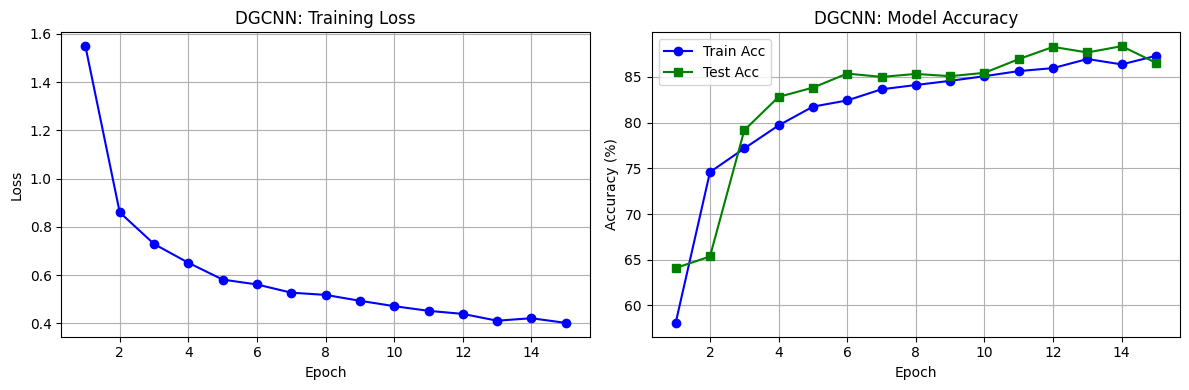


--- Visualizing Final Model Predictions ---


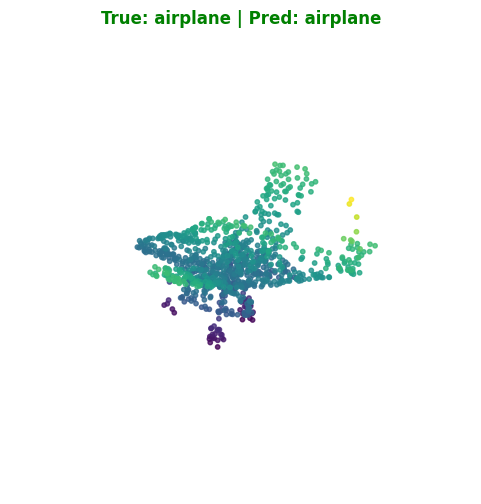

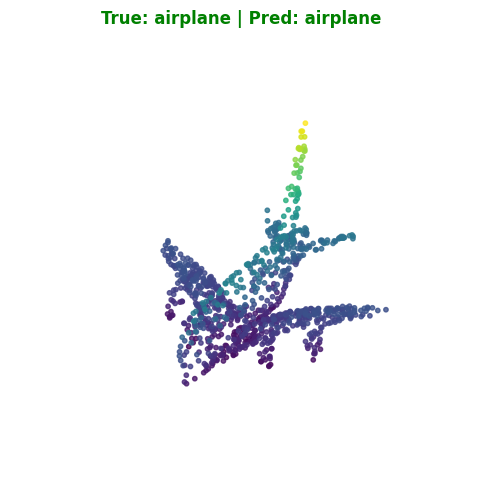

In [ ]:
print("\n--- Generating Training Plots ---")
plot_training_curves(history)
visualize_predictions(model, test_loader, device, num_samples=3)

# **Final Metrics**

In [21]:
def calculate_detailed_metrics(model, test_loader, device, num_classes=40, num_points=1024):
    model.eval()

    # Trackers for oA
    total_correct = 0
    total_samples = 0

    # Trackers for mAcc
    class_correct = np.zeros(num_classes)
    class_total = np.zeros(num_classes)

    with torch.no_grad():
        for data in test_loader:
            # Reshape exactly as done in the training loop
            points = data.pos.view(-1, num_points, 3).transpose(1, 2).to(device)
            labels = data.y.to(device)

            # Get predictions
            outputs = model(points)
            _, predicted = torch.max(outputs.data, 1)

            # 1. Update Overall tracking
            total_samples += labels.size(0)
            total_correct += (predicted == labels).sum().item()

            # 2. Update Class-wise tracking
            for i in range(labels.size(0)):
                label = labels[i].item()
                pred = predicted[i].item()

                class_total[label] += 1
                if label == pred:
                    class_correct[label] += 1

    # Calculate Overall Accuracy (oA)
    oA = total_correct / total_samples

    # Calculate Mean Class Accuracy (mAcc)
    # We use a list comprehension to avoid division by zero in case a class is missing
    class_accuracies = [
        class_correct[i] / class_total[i]
        for i in range(num_classes) if class_total[i] > 0
    ]
    mAcc = np.mean(class_accuracies)

    # Print formatted results
    print("="*40)
    print("FINAL EVALUATION METRICS")
    print("="*40)
    print(f"Overall Accuracy (oA)      : {oA * 100:.2f}%")
    print(f"Mean Class Accuracy (mAcc) : {mAcc * 100:.2f}%")
    print("="*40)

    return oA, mAcc

In [22]:
oA, mAcc = calculate_detailed_metrics(model, test_loader, device)

FINAL EVALUATION METRICS
Overall Accuracy (oA)      : 86.63%
Mean Class Accuracy (mAcc) : 81.02%
